In [2]:
#Import Libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.layers import (
    Input,Conv2D,MaxPooling2D,Flatten,Dense,Dropout
)

In [4]:
#Dataset
(x_train,y_train),(x_test,y_test)=fashion_mnist.load_data()

In [5]:
#Normalise Pixels
x_train=x_train/255.0
x_test=x_test/255.0

In [8]:
#Reshape for CNN
x_train.reshape(-1,28,28,1)
x_test.reshape(-1,28,28,1)

array([[[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]]],


       [[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
 

In [9]:
#Class Name
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

In [11]:
#Model
model=Sequential([
    Input(shape=(28,28,1)),
    Conv2D(32,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(10,activation='softmax')
])

In [13]:
#Model Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
#Model Training
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=2
)


Epoch 1/5
422/422 - 42s - 99ms/step - accuracy: 0.7929 - loss: 0.5953 - val_accuracy: 0.8697 - val_loss: 0.3557
Epoch 2/5
422/422 - 33s - 77ms/step - accuracy: 0.8686 - loss: 0.3784 - val_accuracy: 0.8893 - val_loss: 0.3027
Epoch 3/5
422/422 - 42s - 100ms/step - accuracy: 0.8832 - loss: 0.3327 - val_accuracy: 0.9007 - val_loss: 0.2812
Epoch 4/5
422/422 - 41s - 97ms/step - accuracy: 0.8910 - loss: 0.3058 - val_accuracy: 0.8982 - val_loss: 0.2704
Epoch 5/5
422/422 - 33s - 79ms/step - accuracy: 0.8981 - loss: 0.2860 - val_accuracy: 0.9068 - val_loss: 0.2563


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,081,888 (7.94 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,387,926 (5.29 MB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8996 - loss: 0.2731
Test Accuracy: 0.8996000289916992
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
Predicted: Ankle boot
Actual: Ankle boot


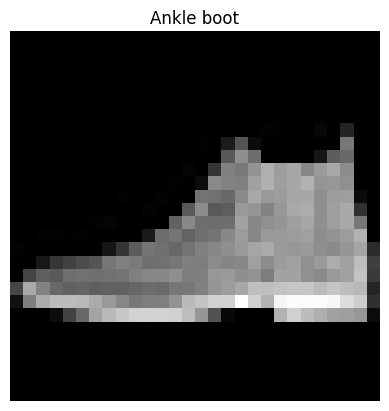

In [16]:
#Model Summary
model.summary()

#Evaluation
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

#Predict one image
prediction = model.predict(x_test[:1])
predicted_class = np.argmax(prediction)
print("Predicted:", class_names[predicted_class])
print("Actual:", class_names[y_test[0]])

#Image
plt.imshow(x_test[0].reshape(28,28), cmap='gray')
plt.title(class_names[y_test[0]])
plt.axis('off')
plt.show()